
# 04 Intervention Effectiveness — Real Data Pipeline

This notebook uses real Lighthouse data to predict **intervention effectiveness** at the **plan level**.

It:
- loads data from `lighthouse_csv_v7.zip`
- engineers real features from intervention plans, sessions, incidents, visits, education, and health data
- uses **during-plan** windows for sessions/incidents/home visits
- trains and evaluates multiple classification pipelines
- tunes a threshold
- saves the best model to `models/intervention_effectiveness_model.pkl`


## Setup and imports
This block imports the Python libraries used throughout the notebook. It brings in tools for loading files, cleaning and transforming data, building machine learning pipelines, evaluating models, and saving the final trained artifact.

In [15]:

import os
import io
import zipfile
import pickle
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

RANDOM_STATE = 42
TEST_SIZE = 0.25
DEFAULT_PLAN_WINDOW_DAYS = 180
ZIP_PATH = Path("lighthouse_csv_v7.zip")


## Load the real Lighthouse data
This block defines helper functions for reading tables from the uploaded `lighthouse_csv_v7.zip` file. It normalizes filenames, loads the required CSVs, and creates the raw dataframes used by the rest of the pipeline.

In [16]:
from pythondbconnection import importTableFromDb

plans = importTableFromDb("dbo.intervention_plans")
residents = importTableFromDb("dbo.residents")
process_recordings = importTableFromDb("dbo.process_recordings")
incident_reports = importTableFromDb("dbo.incident_reports")
health = importTableFromDb("dbo.health_wellbeing_records")
education = importTableFromDb("dbo.education_records")
visits = importTableFromDb("dbo.home_visitations")

for df_name, df in {
    "plans": plans,
    "residents": residents,
    "process_recordings": process_recordings,
    "incident_reports": incident_reports,
    "health": health,
    "education": education,
    "visits": visits,
}.items():
    print(df_name, df.shape)

plans (180, 11)
residents (60, 49)
process_recordings (2810, 15)
incident_reports (100, 12)
health (534, 14)
education (534, 10)
visits (1337, 14)


## Standardize columns and data types
This block defines helper functions that make the notebook more robust to column-name differences and messy values. It finds the right columns, converts booleans safely, and prepares dates and numeric fields so later feature engineering works consistently.

In [17]:

# --- Column helpers ---

def find_col(df, candidates, required=True):
    lookup = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in lookup:
            return lookup[cand.lower()]
    if required:
        raise KeyError(f"Missing column. Tried: {candidates}. Available: {list(df.columns)}")
    return None

def coerce_bool_series(s: pd.Series) -> pd.Series:
    if s is None:
        return s
    if pd.api.types.is_bool_dtype(s):
        return s.fillna(False)
    if pd.api.types.is_numeric_dtype(s):
        return s.fillna(0).astype(float).gt(0)
    lowered = s.astype(str).str.strip().str.lower()
    return lowered.isin(["true", "1", "yes", "y", "completed", "favorable", "resolved"])

def safe_to_datetime(df, candidates):
    col = find_col(df, candidates, required=False)
    if col is None:
        return pd.Series(pd.NaT, index=df.index)
    return pd.to_datetime(df[col], errors="coerce")

def safe_numeric(df, candidates, default=np.nan):
    col = find_col(df, candidates, required=False)
    if col is None:
        return pd.Series(default, index=df.index)
    return pd.to_numeric(df[col], errors="coerce")


## Prepare intervention plan keys and labels
This block identifies the important plan-level columns, standardizes dates, and creates the target variable for the model. The target is whether an intervention is considered effective, which gives the model something real to predict.

In [18]:

# --- Standardize key columns and dates ---

# plans
plan_id_col = find_col(plans, ["plan_id", "intervention_plan_id", "id"])
plan_resident_col = find_col(plans, ["resident_id"])
plan_status_col = find_col(plans, ["status", "plan_status"])
plan_category_col = find_col(plans, ["plan_category", "category", "intervention_type"], required=False)
plan_created = safe_to_datetime(plans, ["created_at", "start_date", "plan_start_date"])
plan_updated = safe_to_datetime(plans, ["updated_at", "end_date", "plan_end_date", "closed_at"])

plans = plans.copy()
plans["plan_id"] = plans[plan_id_col].astype(str)
plans["resident_id"] = plans[plan_resident_col].astype(str)
plans["status_std"] = plans[plan_status_col].astype(str).str.strip()
plans["plan_category_std"] = (
    plans[plan_category_col].astype(str).str.strip() if plan_category_col else "Unknown"
)
plans["created_at_std"] = plan_created
plans["updated_at_std"] = plan_updated
plans["plan_window_end"] = plans["updated_at_std"].fillna(
    plans["created_at_std"] + pd.Timedelta(days=DEFAULT_PLAN_WINDOW_DAYS)
)

# target: effective intervention
plans["effective_intervention"] = (plans["status_std"].str.lower() == "achieved").astype(int)

# process_recordings
proc = process_recordings.copy()
proc["resident_id"] = proc[find_col(proc, ["resident_id"])].astype(str)
proc["recording_id_std"] = proc[find_col(proc, ["recording_id", "process_recording_id", "session_id", "id"], required=False)]     if find_col(proc, ["recording_id", "process_recording_id", "session_id", "id"], required=False) else np.arange(len(proc))
proc["session_date_std"] = safe_to_datetime(proc, ["session_date", "recorded_at", "created_at", "date"])
proc["session_duration_minutes_std"] = safe_numeric(proc, ["session_duration_minutes", "duration_minutes", "session_duration", "duration"])
progress_col = find_col(proc, ["progress_noted", "progress_note", "progress"], required=False)
concerns_col = find_col(proc, ["concerns_flagged", "concern_flagged", "concerns"], required=False)
referral_col = find_col(proc, ["referral_made", "referrals_made", "referred"], required=False)
proc["progress_noted_std"] = coerce_bool_series(proc[progress_col]) if progress_col else False
proc["concerns_flagged_std"] = coerce_bool_series(proc[concerns_col]) if concerns_col else False
proc["referral_made_std"] = coerce_bool_series(proc[referral_col]) if referral_col else False

# incident_reports
inc = incident_reports.copy()
inc["resident_id"] = inc[find_col(inc, ["resident_id"])].astype(str)
inc["incident_id_std"] = inc[find_col(inc, ["incident_id", "id"], required=False)] if find_col(inc, ["incident_id", "id"], required=False) else np.arange(len(inc))
inc["incident_date_std"] = safe_to_datetime(inc, ["incident_date", "created_at", "date"])
severity_col = find_col(inc, ["severity", "severity_level"], required=False)
resolved_col = find_col(inc, ["resolved", "is_resolved", "status"], required=False)
followup_col = find_col(inc, ["follow_up_required", "followup_required", "needs_follow_up"], required=False)
inc["severity_std"] = inc[severity_col].astype(str).str.strip() if severity_col else ""
if resolved_col:
    if inc[resolved_col].dtype == object:
        lowered = inc[resolved_col].astype(str).str.lower().str.strip()
        inc["resolved_std"] = lowered.isin(["true","1","yes","y","resolved","complete","completed"])
    else:
        inc["resolved_std"] = coerce_bool_series(inc[resolved_col])
else:
    inc["resolved_std"] = False
inc["follow_up_required_std"] = coerce_bool_series(inc[followup_col]) if followup_col else False

# visits
vis = visits.copy()
vis["resident_id"] = vis[find_col(vis, ["resident_id"])].astype(str)
vis["visitation_id_std"] = vis[find_col(vis, ["visitation_id", "visit_id", "id"], required=False)] if find_col(vis, ["visitation_id", "visit_id", "id"], required=False) else np.arange(len(vis))
vis["visit_date_std"] = safe_to_datetime(vis, ["visit_date", "created_at", "date"])
safety_col = find_col(vis, ["safety_concerns_noted", "safety_concerns", "safety_issue"], required=False)
followup_visit_col = find_col(vis, ["follow_up_needed", "needs_follow_up"], required=False)
outcome_col = find_col(vis, ["visit_outcome", "outcome", "result"], required=False)
vis["safety_concerns_noted_std"] = coerce_bool_series(vis[safety_col]) if safety_col else False
vis["follow_up_needed_std"] = coerce_bool_series(vis[followup_visit_col]) if followup_visit_col else False
vis["visit_outcome_std"] = vis[outcome_col].astype(str).str.strip() if outcome_col else ""

# education
edu = education.copy()
edu["resident_id"] = edu[find_col(edu, ["resident_id"])].astype(str)
edu["record_date_std"] = safe_to_datetime(edu, ["record_date", "updated_at", "created_at", "date"])
edu["attendance_rate_std"] = safe_numeric(edu, ["attendance_rate"])
edu["progress_percent_std"] = safe_numeric(edu, ["progress_percent", "progress_pct"])
edu_completion_col = find_col(edu, ["completion_status", "status"], required=False)
edu["completion_status_std"] = edu[edu_completion_col].astype(str).str.strip() if edu_completion_col else ""

# health
hlth = health.copy()
hlth["resident_id"] = hlth[find_col(hlth, ["resident_id"])].astype(str)
hlth["record_date_std"] = safe_to_datetime(hlth, ["record_date", "updated_at", "created_at", "date"])
hlth["general_health_score_std"] = safe_numeric(hlth, ["general_health_score"])
hlth["nutrition_score_std"] = safe_numeric(hlth, ["nutrition_score"])
hlth["sleep_quality_score_std"] = safe_numeric(hlth, ["sleep_quality_score"])
hlth["energy_level_score_std"] = safe_numeric(hlth, ["energy_level_score"])
psych_col = find_col(hlth, ["psychological_checkup_done", "psych_check_done"], required=False)
hlth["psychological_checkup_done_std"] = coerce_bool_series(hlth[psych_col]) if psych_col else False


## Engineer real-world features
This block builds the features used for prediction. It summarizes process recordings, incidents, home visits, education progress, and health information into plan-level signals. A key detail is that sessions, incidents, and visits are measured during the intervention window, while education and health are used as baseline context.

In [19]:

# --- Feature engineering ---

# 1) process recordings DURING the plan window
proc_cut = plans[["plan_id", "resident_id", "created_at_std", "plan_window_end"]].merge(
    proc, on="resident_id", how="left"
)

proc_cut = proc_cut[
    proc_cut["session_date_std"].notna()
    & (proc_cut["session_date_std"] >= proc_cut["created_at_std"])
    & (proc_cut["session_date_std"] <= proc_cut["plan_window_end"])
]

proc_agg = proc_cut.groupby("plan_id").agg(
    session_count=("recording_id_std", "count"),
    avg_session_duration=("session_duration_minutes_std", "mean"),
    progress_noted_rate=("progress_noted_std", "mean"),
    concerns_flagged_rate=("concerns_flagged_std", "mean"),
    referral_rate=("referral_made_std", "mean"),
).reset_index()

# 2) incidents DURING the plan window
inc_cut = plans[["plan_id", "resident_id", "created_at_std", "plan_window_end"]].merge(
    inc, on="resident_id", how="left"
)

inc_cut = inc_cut[
    inc_cut["incident_date_std"].notna()
    & (inc_cut["incident_date_std"] >= inc_cut["created_at_std"])
    & (inc_cut["incident_date_std"] <= inc_cut["plan_window_end"])
]

inc_agg = inc_cut.groupby("plan_id").agg(
    incident_count=("incident_id_std", "count"),
    high_severity_incidents=("severity_std", lambda s: int((pd.Series(s).astype(str).str.lower() == "high").sum())),
    unresolved_incidents=("resolved_std", lambda s: int((~pd.Series(s).fillna(False)).sum())),
    follow_up_incidents=("follow_up_required_std", "sum"),
).reset_index()

# 3) home visits DURING the plan window
visit_cut = plans[["plan_id", "resident_id", "created_at_std", "plan_window_end"]].merge(
    vis, on="resident_id", how="left"
)

visit_cut = visit_cut[
    visit_cut["visit_date_std"].notna()
    & (visit_cut["visit_date_std"] >= visit_cut["created_at_std"])
    & (visit_cut["visit_date_std"] <= visit_cut["plan_window_end"])
]

visit_agg = visit_cut.groupby("plan_id").agg(
    visit_count=("visitation_id_std", "count"),
    safety_concerns_noted_count=("safety_concerns_noted_std", "sum"),
    follow_up_needed_count=("follow_up_needed_std", "sum"),
    favorable_visit_count=("visit_outcome_std", lambda s: int((pd.Series(s).astype(str).str.lower() == "favorable").sum())),
).reset_index()

# 4) education BEFORE or at plan start (baseline)
edu_cut = plans[["plan_id", "resident_id", "created_at_std"]].merge(
    edu, on="resident_id", how="left"
)
edu_cut = edu_cut[
    edu_cut["record_date_std"].notna()
    & (edu_cut["record_date_std"] <= edu_cut["created_at_std"])
]
edu_agg = edu_cut.groupby("plan_id").agg(
    avg_attendance_rate=("attendance_rate_std", "mean"),
    max_progress_percent=("progress_percent_std", "max"),
    completed_program_count=("completion_status_std", lambda s: int((pd.Series(s).astype(str).str.lower() == "completed").sum())),
).reset_index()

# 5) health BEFORE or at plan start (baseline: latest available)
hlth_cut = plans[["plan_id", "resident_id", "created_at_std"]].merge(
    hlth, on="resident_id", how="left"
)
hlth_cut = hlth_cut[
    hlth_cut["record_date_std"].notna()
    & (hlth_cut["record_date_std"] <= hlth_cut["created_at_std"])
].sort_values(["plan_id", "record_date_std"])

hlth_last = hlth_cut.groupby("plan_id").tail(1)[[
    "plan_id",
    "general_health_score_std",
    "nutrition_score_std",
    "sleep_quality_score_std",
    "energy_level_score_std",
    "psychological_checkup_done_std",
]].rename(columns={
    "general_health_score_std": "general_health_score",
    "nutrition_score_std": "nutrition_score",
    "sleep_quality_score_std": "sleep_quality_score",
    "energy_level_score_std": "energy_level_score",
    "psychological_checkup_done_std": "psychological_checkup_done",
})


C:\Users\jpfuh\AppData\Local\Temp\ipykernel_24476\1760476328.py:36: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  unresolved_incidents=("resolved_std", lambda s: int((~pd.Series(s).fillna(False)).sum())),


## Assemble the modeling dataset
This block merges all engineered feature tables back into one final dataset with one row per intervention plan. It also cleans missing values, removes all-empty columns, and prepares the final feature set that will feed the model.

In [20]:

# --- Assemble final modeling dataset ---

dataset = plans[[
    "plan_id",
    "resident_id",
    "status_std",
    "plan_category_std",
    "created_at_std",
    "plan_window_end",
    "effective_intervention",
]].copy()

dataset = dataset.merge(proc_agg, on="plan_id", how="left")
dataset = dataset.merge(inc_agg, on="plan_id", how="left")
dataset = dataset.merge(visit_agg, on="plan_id", how="left")
dataset = dataset.merge(edu_agg, on="plan_id", how="left")
dataset = dataset.merge(hlth_last, on="plan_id", how="left")

# useful plan-level feature
dataset["plan_duration_days"] = (dataset["plan_window_end"] - dataset["created_at_std"]).dt.days

# replace all-NaN generated numeric columns with 0 only after merge
for col in dataset.columns:
    if dataset[col].dtype != "O" and not pd.api.types.is_datetime64_any_dtype(dataset[col]):
        dataset[col] = dataset[col].fillna(0)

# drop non-feature / leakage-ish columns
TARGET = "effective_intervention"
drop_cols = ["plan_id", "resident_id", "status_std", "created_at_std", "plan_window_end"]
feature_df = dataset.drop(columns=drop_cols)

# remove columns that are entirely missing just in case
feature_df = feature_df.dropna(axis=1, how="all")

print("Dataset shape:", dataset.shape)
print("Target balance:")
print(dataset[TARGET].value_counts(dropna=False))
print("\nTop missingness:")
display(feature_df.isna().mean().sort_values(ascending=False).head(20))

display(feature_df.head())


Dataset shape: (180, 29)
Target balance:
effective_intervention
0    151
1     29
Name: count, dtype: int64

Top missingness:


follow_up_incidents            0.500000
safety_concerns_noted_count    0.033333
follow_up_needed_count         0.033333
plan_category_std              0.000000
progress_noted_rate            0.000000
effective_intervention         0.000000
session_count                  0.000000
avg_session_duration           0.000000
incident_count                 0.000000
referral_rate                  0.000000
concerns_flagged_rate          0.000000
high_severity_incidents        0.000000
visit_count                    0.000000
unresolved_incidents           0.000000
favorable_visit_count          0.000000
avg_attendance_rate            0.000000
max_progress_percent           0.000000
completed_program_count        0.000000
general_health_score           0.000000
nutrition_score                0.000000
dtype: float64

,plan_category_std,effective_intervention,session_count,avg_session_duration,progress_noted_rate,concerns_flagged_rate,referral_rate,incident_count,high_severity_incidents,unresolved_incidents,...,favorable_visit_count,avg_attendance_rate,max_progress_percent,completed_program_count,general_health_score,nutrition_score,sleep_quality_score,energy_level_score,psychological_checkup_done,plan_duration_days
0,Safety,0,15,65.933333,0.866667,0.200000,0.066667,1.0,0.0,0.0,...,4.0,0.966,37.7,0,3.09,3.02,3.18,2.90,False,152
1,Education,0,15,65.933333,0.866667,0.200000,0.066667,1.0,0.0,0.0,...,4.0,0.966,37.7,0,3.09,3.02,3.18,2.90,False,152
2,Physical Health,0,15,65.933333,0.866667,0.200000,0.066667,1.0,0.0,0.0,...,4.0,0.966,37.7,0,3.09,3.02,3.18,2.90,False,152
3,Safety,0,19,66.526316,0.894737,0.105263,0.105263,0.0,0.0,0.0,...,5.0,0.626,66.8,0,3.19,3.07,3.24,2.84,False,275
4,Education,0,19,66.526316,0.894737,0.105263,0.105263,0.0,0.0,0.0,...,5.0,0.626,66.8,0,3.19,3.07,3.24,2.84,False,275


## Split the data and build preprocessors
This block separates features from the target, creates the train/test split, and defines preprocessing pipelines. Numeric features are imputed and optionally scaled, while categorical features are imputed and one-hot encoded.

In [21]:

# --- Train/test split ---

X = feature_df.drop(columns=[TARGET])
y = feature_df[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

numeric_features = X.select_dtypes(include=[np.number, "bool"]).columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]

preprocessor_for_logreg = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), categorical_features),
    ]
)

preprocessor_for_rf = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), categorical_features),
    ]
)

print("X_train shape:", X_train.shape)
print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))


X_train shape: (135, 23)
Numeric features: 19
Categorical features: 4


## Compare candidate models
This block trains several candidate classifiers using cross-validation and compares them with ROC-AUC and Average Precision. The goal is to identify which model performs best before fitting the final version on the training data.

In [22]:

# --- Model comparison ---

models = {
    "Balanced Logistic Regression": Pipeline([
        ("preprocessor", preprocessor_for_logreg),
        ("model", LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            C=0.7,
            random_state=RANDOM_STATE,
        )),
    ]),
    "Balanced Random Forest": Pipeline([
        ("preprocessor", preprocessor_for_rf),
        ("model", RandomForestClassifier(
            n_estimators=500,
            random_state=RANDOM_STATE,
            class_weight="balanced_subsample",
            min_samples_leaf=2,
            max_features="sqrt",
            n_jobs=-1,
        )),
    ]),
    "Balanced Extra Trees": Pipeline([
        ("preprocessor", preprocessor_for_rf),
        ("model", ExtraTreesClassifier(
            n_estimators=600,
            random_state=RANDOM_STATE,
            class_weight="balanced",
            min_samples_leaf=2,
            max_features="sqrt",
            n_jobs=-1,
        )),
    ]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []

for name, pipe in models.items():
    roc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc").mean()
    ap = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="average_precision").mean()
    results.append({"model": name, "cv_roc_auc": roc, "cv_ap": ap})

results_df = pd.DataFrame(results).sort_values(["cv_roc_auc", "cv_ap"], ascending=False)
display(results_df)


,model,cv_roc_auc,cv_ap
2,Balanced Extra Trees,0.726166,0.480964
0,Balanced Logistic Regression,0.694585,0.372581
1,Balanced Random Forest,0.685534,0.476942


## Fit the best model and tune the threshold
This block fits the best-performing pipeline on the training set and uses predicted probabilities on the holdout set to test multiple classification thresholds. Threshold tuning helps balance precision and recall instead of relying on the default 0.50 cutoff.

In [23]:

# --- Fit best model and tune threshold on holdout ---

best_model_name = results_df.iloc[0]["model"]
best_pipe = models[best_model_name]
best_pipe.fit(X_train, y_train)

y_proba = best_pipe.predict_proba(X_test)[:, 1]

threshold_grid = np.arange(0.30, 0.71, 0.05)
threshold_rows = []

for th in threshold_grid:
    pred = (y_proba >= th).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    precision = tp / (tp + fp) if (tp + fp) else 0
    recall = tp / (tp + fn) if (tp + fn) else 0
    threshold_rows.append({
        "threshold": th,
        "precision": precision,
        "recall": recall,
        "youden_proxy": precision + recall,
    })

threshold_df = pd.DataFrame(threshold_rows).sort_values(
    ["youden_proxy", "recall", "precision"], ascending=False
)
best_threshold = float(threshold_df.iloc[0]["threshold"])
display(threshold_df)

print("Best model:", best_model_name)
print("Best threshold:", best_threshold)
print("Holdout ROC-AUC:", roc_auc_score(y_test, y_proba))
print("Holdout AP:", average_precision_score(y_test, y_proba))


,threshold,precision,recall,youden_proxy
3,0.45,0.300000,0.428571,0.728571
2,0.40,0.272727,0.428571,0.701299
1,0.35,0.250000,0.428571,0.678571
0,0.30,0.230769,0.428571,0.659341
4,0.50,0.250000,0.285714,0.535714
5,0.55,0.250000,0.285714,0.535714
8,0.70,0.333333,0.142857,0.476190
6,0.60,0.250000,0.142857,0.392857
7,0.65,0.250000,0.142857,0.392857


Best model: Balanced Extra Trees
Best threshold: 0.44999999999999996
Holdout ROC-AUC: 0.6203007518796992
Holdout AP: 0.2699895342752485


## Final evaluation
This block applies the chosen threshold to the holdout predictions and prints the final evaluation outputs. The confusion matrix and classification report show how well the model distinguishes effective from ineffective interventions.

Best model: Balanced Extra Trees
ROC-AUC: 0.6203
Average Precision: 0.27

               precision    recall  f1-score   support

Not Effective       0.89      0.82      0.85        38
    Effective       0.30      0.43      0.35         7

     accuracy                           0.76        45
    macro avg       0.59      0.62      0.60        45
 weighted avg       0.79      0.76      0.77        45



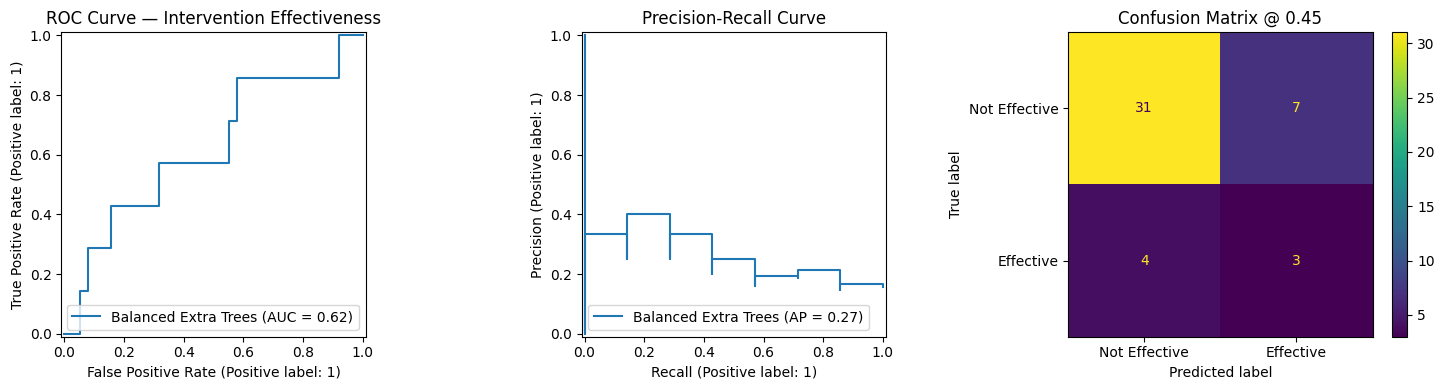

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    ConfusionMatrixDisplay,
)

# Fallbacks in case these variables were not set earlier
if "best_threshold" not in globals():
    best_threshold = 0.5

if "best_model_name" not in globals():
    best_model_name = "Best Model"

# If y_proba was not created yet, create it from best_pipe
if "y_proba" not in globals():
    y_proba = best_pipe.predict_proba(X_test)[:, 1]

# If y_proba accidentally has 2 columns, keep only positive-class probs
if hasattr(y_proba, "ndim") and y_proba.ndim > 1:
    y_proba = y_proba[:, 1]

y_pred = (y_proba >= best_threshold).astype(int)

print("Best model:", best_model_name)

if y_test.nunique() > 1:
    print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))
else:
    print("ROC-AUC: undefined (only one class present in y_test)")

print("Average Precision:", round(average_precision_score(y_test, y_proba), 4))
print()
print(classification_report(y_test, y_pred, target_names=["Not Effective", "Effective"]))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

if y_test.nunique() > 1:
    RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[0], name=best_model_name)
    axes[0].set_title("ROC Curve — Intervention Effectiveness")
else:
    axes[0].text(0.5, 0.5, "ROC curve unavailable\n(only one class in y_test)", ha="center", va="center")
    axes[0].set_title("ROC Curve — Intervention Effectiveness")
    axes[0].set_axis_off()

PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[1], name=best_model_name)
axes[1].set_title("Precision-Recall Curve")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["Not Effective", "Effective"], ax=axes[2]
)
axes[2].set_title(f"Confusion Matrix @ {best_threshold:.2f}")

plt.tight_layout()
plt.show()

## Save the standardized model artifact
This block saves the trained pipeline in the same artifact format used by the other notebooks in the project. It stores the model, feature list, threshold, and target name, then shows a few example predictions to demonstrate how the artifact can be used.

In [25]:

# --- Save model in standardized format ---

import pickle, os
import pandas as pd

os.makedirs("models", exist_ok=True)

# Keep feature list consistent
selected_features = list(X_train.columns)

# Final trained pipeline
final_model = best_pipe

# Save artifact
with open("models/intervention_effectiveness_model.pkl", "wb") as f:
    pickle.dump({
        "model": final_model,
        "features": selected_features,
        "threshold": best_threshold if 'best_threshold' in globals() else 0.5,
        "target_name": "effective_intervention"
    }, f)

print("Model saved to models/intervention_effectiveness_model.pkl")

# Example scoring
new_cases = X_test[selected_features].iloc[:5].copy()
probs = final_model.predict_proba(new_cases)[:, 1]

new_cases["success_probability"] = probs
new_cases["prediction"] = (probs >= (best_threshold if 'best_threshold' in globals() else 0.5)).astype(int)

new_cases["effectiveness_tier"] = pd.cut(
    new_cases["success_probability"],
    bins=[0, 0.4, 0.65, 1.0],
    labels=["Low", "Medium", "High"]
)

print(new_cases[["success_probability", "prediction", "effectiveness_tier"]])


Model saved to models/intervention_effectiveness_model.pkl
     success_probability  prediction effectiveness_tier
70              0.311546           0                Low
155             0.223147           0                Low
129             0.063623           0                Low
72              0.589948           1             Medium
40              0.495921           1             Medium
